# Óptica y alcance — ¿qué lente y resolución ven humo a 1–10 km?

Nodo fijo (llano, monte 8–12 m), ESP32-S3 + OV2640 (p = 2.2 µm) u OV5640 (p = 1.4 µm), lente M12, foto cada 15 min. La lógica vive en `modulos/optica.py`; acá sólo se mide y grafica.

Pregunta: ¿qué focal M12 (3.6/8/12/16/25 mm) y qué captura (UXGA/SVGA/QVGA/96×96) dejan una columna de humo (10/20/40 m) y una llama (2 m) por encima de ~3 px (detección) y ~8 px (caracterización) entre 1 y 10 km?

```bash
cd Desarrollo/Pruebas
uv run jupyter lab notebooks/8_optica_alcance.ipynb
```


In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as W
from ipywidgets import interact
# Raiz = carpeta con modulos/, como en 2_horizonte.ipynb
RAIZ = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / "modulos").is_dir()), None)
if RAIZ is None:
    raise RuntimeError(f"no encuentro 'modulos/' desde {Path.cwd()}")
sys.path.insert(0, str(RAIZ / "modulos"))
def ruta_salida(n):
    (RAIZ / "salidas").mkdir(parents=True, exist_ok=True)
    return RAIZ / "salidas" / n
import optica as op
import nn_esp32 as nn
plt.rcParams.update({"figure.dpi": 110, "font.size": 8})
DIST = np.array([1000, 2000, 5000, 10000])


## 1 · GSD, IFOV y FOV por lente y sensor

GSD = p·D/f. El píxel efectivo crece al capturar por debajo del nativo (QVGA = 5× en OV2640).


In [2]:
for s in ("OV2640", "OV5640"):
    print(f"== {s} (p={op.SENSORES[s]['p_um']} um) ==")
    print("f[mm]  HFOV[°] VFOV[°] IFOV[mrad]" + "".join(f" GSD@{d//1000}k[m]" for d in DIST))
    for f in op.FOCALES_MM:
        hf, vf = op.fov_grados(s, f)
        g = [op.gsd(op.SENSORES[s]["p_um"], d, f) for d in DIST]
        print(f"{f:5.1f} {hf:7.1f} {vf:6.1f} {op.ifov_mrad(op.SENSORES[s]['p_um'], f):9.3f}" + "".join(f"{v:9.2f}" for v in g))
print("\np_efecto [um]:", {c: round(op.pixel_efectivo_um("OV2640", c), 2) for c in op.CAPTURAS})


== OV2640 (p=2.2 um) ==
f[mm]  HFOV[°] VFOV[°] IFOV[mrad] GSD@1k[m] GSD@2k[m] GSD@5k[m] GSD@10k[m]
  3.6    52.1   40.3     0.611     0.61     1.22     3.06     6.11
  8.0    24.8   18.7     0.275     0.28     0.55     1.38     2.75
 12.0    16.7   12.6     0.183     0.18     0.37     0.92     1.83
 16.0    12.6    9.4     0.138     0.14     0.28     0.69     1.38
 25.0     8.1    6.0     0.088     0.09     0.18     0.44     0.88
== OV5640 (p=1.4 um) ==
f[mm]  HFOV[°] VFOV[°] IFOV[mrad] GSD@1k[m] GSD@2k[m] GSD@5k[m] GSD@10k[m]
  3.6    53.5   41.4     0.389     0.39     0.78     1.94     3.89
  8.0    25.6   19.3     0.175     0.17     0.35     0.87     1.75
 12.0    17.2   12.9     0.117     0.12     0.23     0.58     1.17
 16.0    12.9    9.7     0.087     0.09     0.17     0.44     0.87
 25.0     8.3    6.2     0.056     0.06     0.11     0.28     0.56

p_efecto [um]: {'UXGA': 2.2, 'SVGA': 4.4, 'QVGA': 11.0, '96x96': 36.67}


## 2 · Píxeles sobre el blanco vs distancia

Líneas en 3 px (detección) y 8 px (caracterización). La llama nocturna de 2 m es fuente puntual: se ve por PSF/blooming, no por geometría.


In [ ]:
@interact(sensor=["OV2640", "OV5640"], captura=list(op.CAPTURAS), focal=op.FOCALES_MM)
def _px(sensor="OV2640", captura="UXGA", focal=16.0):
    d = np.linspace(500, 10000, 200)
    pe = op.pixel_efectivo_um(sensor, captura)
    fig, ax = plt.subplots(figsize=(7, 3.2))
    for w, ls in ((40, "-"), (20, "--"), (10, ":"), (2, "-.")):
        ax.plot(d / 1000, [op.pixeles_blanco(w, pe, dd, focal) for dd in d], ls, label=f"{w} m")
    for u, cc in ((op.PX_DETECT, "k"), (op.PX_CARACT, "r")):
        ax.axhline(u, color=cc, lw=1, label=f"umbral {u:g} px")
    ax.set(xlabel="distancia [km]", ylabel="píxeles", title=f"{sensor} f={focal:g} mm {captura} (p_ef={pe:.2f} um)")
    ax.set_ylim(0.3, 300); ax.set_yscale("log"); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    plt.show()


interactive(children=(Dropdown(description='sensor', options=('OV2640', 'OV5640'), value='OV2640'), Dropdown(d…

## 3 · Tiles de horizonte y costo energético

Sólo se infiere la franja sobre el horizonte (alto parametrizable); cada tile es 96×96 (entrada de la red). Costo con `nn_esp32` (MobileNetV1 α=0.25, ESP32-S3) vs reposo de 15 min.


In [4]:
@interact(focal=op.FOCALES_MM, alto_franja=[2.0, 4.0, 8.0])
def _tiles(focal=16.0, alto_franja=4.0):
    hf, vf = op.fov_grados("OV2640", focal)
    n, frac = op.tiles_franja(hf, vf, alto_franja_deg=alto_franja, w_cap=1600, h_cap=1200)
    p = nn.perfil(alpha=0.25, res=96, canales_in=1)
    e = nn.energia_captura(p, chip="esp32s3", p_disparo=1.0)
    e_tiles_J = n * (e["e_clasico"] + e["e_nn"]) / 1000
    e_sleep_J = 5.0 * nn.MA_SLEEP_MOSFET / 1000 * 900
    print(f"HFOV={hf:.1f}° VFOV={vf:.1f}° -> {n} tiles 96×96 (frac. frame={frac:.2f})")
    print(f"inferencia: {n}x{nn.latencia_ms(p, 'esp32s3'):.0f} ms = {n * nn.latencia_ms(p, 'esp32s3') / 1000:.1f} s, {e_tiles_J:.2f} J")
    print(f"reposo 15 min (MOSFET, {nn.MA_SLEEP_MOSFET} mA): {e_sleep_J:.2f} J")
    print("conclusion: la inferencia de N tiles cuesta mas que UNA captura; el reposo manda en el dia (ver nn_esp32.autonomia).")
    fig, ax = plt.subplots(figsize=(6, 2.6))
    ax.bar(["tiles", "reposo 15 min"], [e_tiles_J, e_sleep_J]); ax.set_ylabel("energía [J]"); plt.show()


interactive(children=(Dropdown(description='focal', index=3, options=(3.6, 8.0, 12.0, 16.0, 25.0), value=16.0)…

## 4 · Nodos para 360° y cobertura doble

Con HFOV ~12.5° un nodo cubre un sector; la triangulación exige que dos nodos vean la misma zona (doble).


In [5]:
print(f"{'f[mm]':>6} {'HFOV':>6} {'nodos':>6} {'doble':>6}")
for f in op.FOCALES_MM:
    hf, _ = op.fov_grados("OV2640", f)
    print(f"{f:6.1f} {hf:6.1f} {op.nodos_360(hf):6d} {op.nodos_360(hf, True):6d}")


 f[mm]   HFOV  nodos  doble
   3.6   52.1      7     14
   8.0   24.8     15     30
  12.0   16.7     22     44
  16.0   12.6     29     58
  25.0    8.1     45     90


## 5 · Oclusión: dosel y curvatura

El rayo a la base pasa a H_cam·d/D; con monte de 10 m a 500 m del foco un mástil de 15 m sólo ve la base hasta 1.5 km. A >3–4 km sólo emerge la columna. Caída por curvatura (R'e 4/3): D²/2R'e.


In [6]:
Hs = np.arange(5, 41, 5)
print("H[m]  Dmax_base[m]  h_min(D=5k)[m]  h_min(D=10k)[m]  caida@10k[m]")
for H in Hs:
    print(f"{H:4d} {op.dmax_base_visible_m(H):13.0f} {op.altura_min_visible_m(H, 5000):15.1f} {op.altura_min_visible_m(H, 10000):16.1f} {op.caida_curvatura_m(10000):13.2f}")


H[m]  Dmax_base[m]  h_min(D=5k)[m]  h_min(D=10k)[m]  caida@10k[m]
   5             0            10.6             10.3          5.89
  10             0            10.0             10.0          5.89
  15          1500             9.4              9.7          5.89
  20          1000             8.9              9.5          5.89
  25           833             8.3              9.2          5.89
  30           750             7.8              8.9          5.89
  35           700             7.2              8.7          5.89
  40           667             6.7              8.4          5.89


## 6 · Sensibilidad monocular ΔD ≈ D²/H·Δθ

En llanura el error crece con D²: a 5 km y H = 20 m, 0.05° ya son ~1 km. Por eso la distancia de un solo nodo es cota gruesa y la triangulación (§5.2 del informe) es la medición.


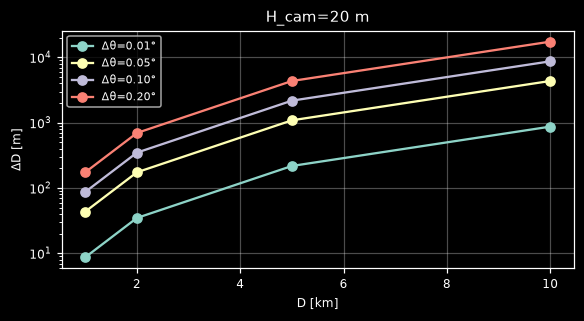

H=10–40 m: el error escala 1/H; duplicar el mástil lo divide por 2, nada más.


In [7]:
Ds = np.array([1000, 2000, 5000, 10000]); dth = np.radians([0.01, 0.05, 0.1, 0.2]); H = 20
fig, ax = plt.subplots(figsize=(6, 2.8))
for t in dth:
    ax.plot(Ds / 1000, [op.sensibilidad_mono_m(d, H, t) for d in Ds], "o-", label=f"Δθ={np.degrees(t):.2f}°")
ax.set(xlabel="D [km]", ylabel="ΔD [m]", title=f"H_cam={H} m"); ax.set_yscale("log"); ax.legend(fontsize=7); ax.grid(True, alpha=0.3); plt.show()
print("H=10–40 m: el error escala 1/H; duplicar el mástil lo divide por 2, nada más.")


## 7 · Exportar y conclusión

Salida: `salidas/optica_alcance.csv` (GSD y píxeles por focal/distancia).


In [8]:
import csv
rows = []
for s in ("OV2640", "OV5640"):
    for f in op.FOCALES_MM:
        hf, vf = op.fov_grados(s, f)
        for D in DIST:
            g = op.gsd(op.SENSORES[s]["p_um"], D, f)
            rows.append(dict(sensor=s, f_mm=f, hfov=round(hf, 2), D_m=D, gsd_m=round(g, 3),
                             px_humo10m=round(10 / g, 2), px_llama2m=round(2 / g, 2)))
with open(ruta_salida("optica_alcance.csv"), "w", newline="") as fh:
    fh.write(",".join(rows[0]) + "\n")
    for r in rows:
        fh.write(",".join(str(v) for v in r.values()) + "\n")
print(f"{len(rows)} filas -> {ruta_salida('optica_alcance.csv')}")
print("CONCLUSION: lente M12 f=16 mm + captura a resolucion nativa (sin reducir): humo 10 m ~14 px @5 km, ~7 px @10 km. La stock 3.6 mm no llega (3 px @5 km) y reducir a QVGA/96×96 destruye la deteccion: inferir tiles 96×96 sobre el frame completo, no sobre un frame reducido.")



40 filas -> /home/gabi/Documentos/FaCENA/proyecto_final/Desarrollo/Pruebas/salidas/optica_alcance.csv
CONCLUSION: lente M12 f=16 mm + captura a resolucion nativa (sin reducir): humo 10 m ~14 px @5 km, ~7 px @10 km. La stock 3.6 mm no llega (3 px @5 km) y reducir a QVGA/96×96 destruye la deteccion: inferir tiles 96×96 sobre el frame completo, no sobre un frame reducido.
